**Tahapan Knowledge Discovery in Database (KDD)**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ==========================================
# SIMULASI DATASET MENTAH (Raw Data)
# ==========================================
# Membuat data tiruan yang mencerminkan kondisi lapangan untuk simulasi
np.random.seed(42)
n_samples = 150

raw_data = {
    'shuttle_id': np.random.choice(['SK01', 'SK02', 'SK03', 'SK04', 'SK05'], n_samples),
    'waktu_tunggu_menit': np.random.randint(5, 45, n_samples), # Kendala jadwal tidak pasti
    'kapasitas_kursi_tersedia': np.random.randint(0, 15, n_samples), # Kendala kursi
    'status_baterai_persen': np.random.randint(5, 100, n_samples), # Kendala daya baterai
    'rating_kepuasan': np.random.choice([1, 2, 3, 4, 5, np.nan], n_samples, p=[0.1, 0.1, 0.2, 0.3, 0.25, 0.05]),
    'koordinat_gps': [f"-7.04{np.random.randint(100,999)},110.40{np.random.randint(100,999)}" for _ in range(n_samples)]
}
df_raw = pd.DataFrame(raw_data)
# Duplikasi data sengaja dibuat untuk tahap cleaning
df_raw = pd.concat([df_raw, df_raw.iloc[[10, 25, 50]]], ignore_index=True)

print("--- RAW DATA SECARA UMUM ---")
print(df_raw.head(), "\n" + "="*50)


# ==========================================
# 1. DATA SELECTION (Seleksi Data)
# ==========================================
# Memilih fitur/variabel yang relevan dengan tujuan penelitian deskriptif
# Mengabaikan koordinat GPS mentah (String) untuk kebutuhan modeling numerik
fitur_terpilih = ['shuttle_id', 'waktu_tunggu_menit', 'kapasitas_kursi_tersedia', 'status_baterai_persen', 'rating_kepuasan']
df_selected = df_raw[fitur_terpilih].copy()

print("\n[1] DATA SELECTION RESULT (Fitur Relevan Terpilih):")
print(df_selected.head())


# ==========================================
# 2. DATA CLEANING (Pembersihan Data)
# ==========================================
# A. Menghapus data duplikat
df_cleaned = df_selected.drop_duplicates().copy()

# B. Menangani Missing Values (Data Kosong) pada rating_kepuasan dengan nilai Median
median_rating = df_cleaned['rating_kepuasan'].median()
df_cleaned['rating_kepuasan'] = df_cleaned['rating_kepuasan'].fillna(median_rating)

print(f"\n[2] DATA CLEANING RESULT:")
print(f"Jumlah baris awal: {len(df_selected)} -> Setelah dibersihkan: {len(df_cleaned)}")


# ==========================================
# 3. DATA TRANSFORMATION (Transformasi Data)
# ==========================================
# Mengelompokkan atau menyelaraskan data agar siap masuk ke algoritma data mining
# Membuat kategori deskriptif baru berdasarkan kombinasi variabel kendala
def transformasi_kendala(row):
    # Jika waktu tunggu lama dan baterai tipis, dikategorikan Kendala Tinggi
    if row['waktu_tunggu_menit'] > 25 or row['status_baterai_persen'] < 20:
        return 1 # Kategori: Potensi Kendala Tinggi
    else:
        return 0 # Kategori: Operasional Lancar

df_transformed = df_cleaned.copy()
df_transformed['indeks_kendala'] = df_transformed.apply(transformasi_kendala, axis=1)

print("\n[3] DATA TRANSFORMATION RESULT (Penambahan Indeks Kendala):")
print(df_transformed[['waktu_tunggu_menit', 'status_baterai_persen', 'indeks_kendala']].head())


# ==========================================
# 4. DATA MINING / MODELING (Klastering Deskriptif)
# ==========================================
# Menggunakan K-Means Clustering untuk memetakan profil pelayanan shuttle
# Fitur yang digunakan untuk modeling
X = df_transformed[['waktu_tunggu_menit', 'status_baterai_persen', 'rating_kepuasan']]

# Membentuk 3 Cluster (Contoh: Layanan Buruk, Layanan Standar, Layanan Sangat Baik)
kmeans = KMeans(n_clusters=3, random_state=42)
df_transformed['cluster'] = kmeans.fit_predict(X)

print("\n[4] DATA MINING RESULT (Pengelompokan Karakteristik Layanan):")
# Menampilkan rata-rata tiap cluster untuk diinterpretasikan
analisis_cluster = df_transformed.groupby('cluster')[['waktu_tunggu_menit', 'status_baterai_persen', 'rating_kepuasan']].mean()
print(analisis_cluster)


# ==========================================
# 5. INTERPRETATION / EVALUATION (Interpretasi)
# ==========================================
print("\n" + "="*50 + "\n[5] INTERPRETATION & KESIMPULAN DESKRIPTIF:\n" + "="*50)
for cluster_id in range(3):
    sub_cluster = analisis_cluster.loc[cluster_id]
    print(f"--- Karakteristik Cluster {cluster_id} ---")
    print(f"  * Rata-rata Waktu Tunggu : {sub_cluster['waktu_tunggu_menit']:.1f} menit")
    print(f"  * Rata-rata Sisa Baterai : {sub_cluster['status_baterai_persen']:.1f}%")
    print(f"  * Rata-rata Kepuasan     : {sub_cluster['rating_kepuasan']:.1f}/5.0")

    # Narasi Interpretasi Otomatis
    if sub_cluster['rating_kepuasan'] >= 4.0:
        print("  > INTERPRETASI: Klaster Layanan Prima. Penumpang puas karena waktu tunggu relatif singkat dan performa baterai aman.")
    elif sub_cluster['waktu_tunggu_menit'] > 25.0:
        print("  > INTERPRETASI: Klaster Kendala Operasional (Waktu). Efisiensi mobilitas terhambat akibat waktu tunggu yang lama.")
    else:
        print("  > INTERPRETASI: Klaster Layanan Cukup/Standar. Perlu optimalisasi jadwal agar tingkat kepuasan meningkat.")
    print("-" * 40)

--- RAW DATA SECARA UMUM ---
  shuttle_id  waktu_tunggu_menit  kapasitas_kursi_tersedia  \
0       SK04                  29                         7   
1       SK05                  43                        12   
2       SK03                  37                         0   
3       SK05                   5                        13   
4       SK05                  31                         4   

   status_baterai_persen  rating_kepuasan       koordinat_gps  
0                     26              5.0  -7.04645,110.40873  
1                     97              4.0  -7.04152,110.40549  
2                     71              2.0  -7.04304,110.40225  
3                     80              1.0  -7.04846,110.40142  
4                     30              5.0  -7.04851,110.40982   

[1] DATA SELECTION RESULT (Fitur Relevan Terpilih):
  shuttle_id  waktu_tunggu_menit  kapasitas_kursi_tersedia  \
0       SK04                  29                         7   
1       SK05                  43    

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# ==========================================
# 0. SIMULASI DATASET (Untuk Keperluan Demo)
# ==========================================
# Membuat data tiruan agar kode bisa langsung dijalankan
np.random.seed(42)
data_dummy = {
    'id_kurir': range(1, 101),
    'koordinat_gps': [f"{np.random.uniform(-6.2, -6.1)}, {np.random.uniform(106.8, 106.9)}" for _ in range(100)],
    'waktu_tunggu_menit': np.random.randint(5, 60, size=100),
    'sisa_baterai_persen': np.random.randint(10, 100, size=100),
    'kepuasan_pelanggan': np.random.choice([1.0, 2.0, 3.0, 4.0, 5.0, np.nan], size=100, p=[0.1, 0.1, 0.2, 0.3, 0.2, 0.1])
}
df_mentah = pd.DataFrame(data_dummy)

# Menambahkan beberapa data duplikat untuk simulasi pembersihan
df_mentah = pd.concat([df_mentah, df_mentah.iloc[:5]], ignore_index=True)


# ==========================================
# 1. DATA SELECTION
# ==========================================
print("--- STAGE 1: DATA SELECTION ---")
# Menyaring kolom string/identitas yang tidak diperlukan untuk pemodelan kuantitatif
kolom_fitur = ['waktu_tunggu_menit', 'sisa_baterai_persen', 'kepuasan_pelanggan']
df_seleksi = df_mentah[kolom_fitur].copy()

print(f"Data awal: {df_mentah.shape[0]} baris, {df_mentah.shape[1]} kolom.")
print(f"Data setelah seleksi fitur: {df_seleksi.shape[0]} baris, {df_seleksi.shape[1]} kolom.")
print("Kolom 'koordinat_gps' berhasil dikesampingkan.\n")


# ==========================================
# 2. DATA CLEANING
# ==========================================
print("--- STAGE 2: DATA CLEANING ---")
# A. Menghapus duplikasi baris
df_bersih = df_seleksi.drop_duplicates().copy()
print(f"Jumlah baris duplikat yang dihapus: {len(df_seleksi) - len(df_bersih)}")

# B. Menambal nilai NaN (kosong) pada kolom kepuasan menggunakan nilai median
median_kepuasan = df_bersih['kepuasan_pelanggan'].median()
df_bersih['kepuasan_pelanggan'] = df_bersih['kepuasan_pelanggan'].fillna(median_kepuasan)
print(f"Nilai NaN pada kolom kepuasan berhasil ditambal dengan nilai median: {median_kepuasan}\n")


# ==========================================
# 3. DATA TRANSFORMATION
# ==========================================
print("--- STAGE 3: DATA TRANSFORMATION ---")
# Membuat pengelompokan baru berdasarkan ambang batas kendala operasional
# Contoh: Batas kritis waktu tunggu > 30 menit, dan Baterai Kritis < 30%
df_transformasi = df_bersih.copy()

df_transformasi['status_waktu_tunggu'] = np.where(df_transformasi['waktu_tunggu_menit'] > 30, 'Lama', 'Normal')
df_transformasi['status_baterai'] = np.where(df_transformasi['sisa_baterai_persen'] < 30, 'Kritis', 'Aman')

print("Berhasil membuat fitur transformasi baru berbasis ambang batas kendala operasional.")
print(df_transformasi[['waktu_tunggu_menit', 'status_waktu_tunggu', 'sisa_baterai_persen', 'status_baterai']].head(), "\n")


# ==========================================
# 4. DATA MINING (CLUSTERING)
# ==========================================
print("--- STAGE 4: DATA MINING (CLUSTERING) ---")
# Menentukan fitur operasional (X) untuk clustering
# Kita gunakan waktu tunggu dan sisa baterai sebagai variabel operasional
X = df_transformasi[['waktu_tunggu_menit', 'sisa_baterai_persen']]

# Menggunakan algoritma K-Means untuk membagi data menjadi 3 kelompok profil (klaster)
kmeans = KMeans(n_clusters=3, random_state=42)
df_transformasi['cluster'] = kmeans.fit_predict(X)

print("Proses clustering K-Means selesai. Setiap baris data telah diberikan label kelompok otomatis.\n")


# ==========================================
# 5. INTERPRETATION
# ==========================================
print("--- STAGE 5: INTERPRETATION (Untuk Bab IV Proposal) ---")
# Mengekstrak nilai pusat dari setiap klaster (centroid) dan variabel dampaknya (Y)
kesimpulan_klaster = df_transformasi.groupby('cluster').agg({
    'waktu_tunggu_menit': 'mean',
    'sisa_baterai_persen': 'mean',
    'kepuasan_pelanggan': 'mean',
    'cluster': 'count'
}).rename(columns={'cluster': 'jumlah_sampel'})

print("MATRIKS CENTROID & DAMPAK KLASTER:")
print(kesimpulan_klaster.round(2))
print("-" * 50)

# Narasi Kesimpulan Otomatis untuk Bab IV
print("\n[DRAF NARASI BAB IV PROPOSAL ANDA]:")
for cluster_id, row in kesimpulan_klaster.iterrows():
    print(f"Berdasarkan hasil analisis K-Means, Klaster {int(cluster_id)} "
          f"(n = {int(row['jumlah_sampel'])} data) merepresentasikan profil operasional dengan "
          f"rata-rata waktu tunggu {row['waktu_tunggu_menit']:.1f} menit dan rata-rata sisa baterai {row['sisa_baterai_persen']:.1f}%. "
          f"Kondisi operasional pada profil ini menghasilkan dampak terhadap kepuasan pelanggan sebesar {row['kepuasan_pelanggan']:.2f} dari skala 5.0.")

--- STAGE 1: DATA SELECTION ---
Data awal: 105 baris, 5 kolom.
Data setelah seleksi fitur: 105 baris, 3 kolom.
Kolom 'koordinat_gps' berhasil dikesampingkan.

--- STAGE 2: DATA CLEANING ---
Jumlah baris duplikat yang dihapus: 5
Nilai NaN pada kolom kepuasan berhasil ditambal dengan nilai median: 4.0

--- STAGE 3: DATA TRANSFORMATION ---
Berhasil membuat fitur transformasi baru berbasis ambang batas kendala operasional.
   waktu_tunggu_menit status_waktu_tunggu  sisa_baterai_persen status_baterai
0                  28              Normal                   41           Aman
1                  56                Lama                   56           Aman
2                  15              Normal                   95           Aman
3                  53                Lama                   32           Aman
4                  12              Normal                   75           Aman 

--- STAGE 4: DATA MINING (CLUSTERING) ---
Proses clustering K-Means selesai. Setiap baris data telah diberi

### Menghitung Jumlah Sampel per Klaster

Untuk mengetahui distribusi data di antara klaster-klaster yang telah terbentuk, kita akan menghitung berapa banyak sampel yang ada di setiap klaster.

Jumlah sampel dalam setiap klaster:
cluster
0    20
1    46
2    34
Name: count, dtype: int64


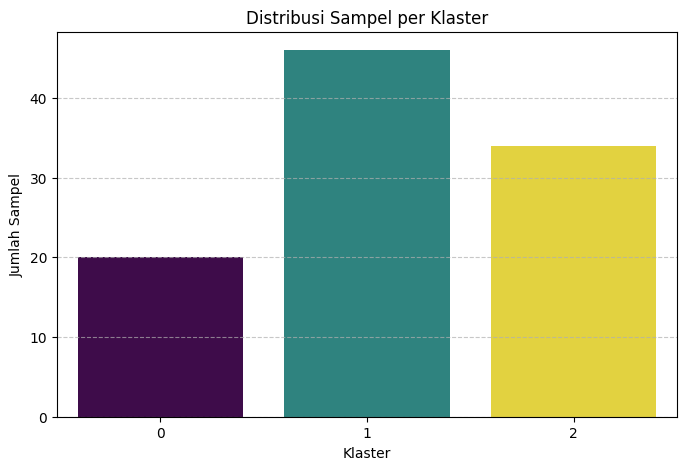

In [ ]:
jumlah_sampel_per_klaster = df_transformasi['cluster'].value_counts().sort_index()
print("Jumlah sampel dalam setiap klaster:")
print(jumlah_sampel_per_klaster)

# Visualisasi jumlah sampel per klaster
plt.figure(figsize=(8, 5))
sns.barplot(x=jumlah_sampel_per_klaster.index, y=jumlah_sampel_per_klaster.values, hue=jumlah_sampel_per_klaster.index, palette='viridis', legend=False)
plt.title('Distribusi Sampel per Klaster')
plt.xlabel('Klaster')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Menyimpan Hasil Klastering ke File CSV

Setelah melakukan klastering dan mendapatkan hasil pengelompokan, langkah selanjutnya adalah menyimpan data yang sudah diperkaya dengan informasi klaster ke dalam sebuah file CSV. Ini memungkinkan Anda untuk menggunakan hasil ini di lain waktu atau di aplikasi lain.

In [ ]:
output_filename = 'hasil_klastering.csv'
df_transformasi.to_csv(output_filename, index=False)
print(f"Hasil klastering telah disimpan ke '{output_filename}'")

Hasil klastering telah disimpan ke 'hasil_klastering.csv'


### Visualisasi Hasil Clustering

Untuk lebih memahami karakteristik setiap klaster, mari kita visualisasikan data dengan *scatter plot*. Kita akan memplot `waktu_tunggu_menit` terhadap `sisa_baterai_persen`, dan mewarnai setiap titik berdasarkan klaster yang telah ditetapkan oleh algoritma K-Means.

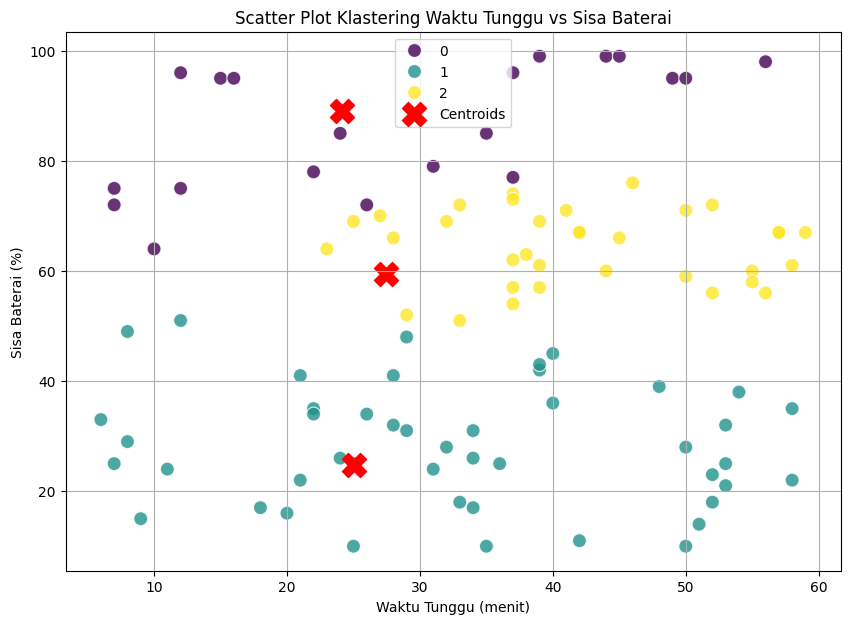

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='waktu_tunggu_menit',
    y='sisa_baterai_persen',
    hue='cluster',
    data=df_transformasi,
    palette='viridis',
    s=100, # Ukuran titik
    alpha=0.8 # Transparansi titik
)

# Menambahkan centroid klaster untuk referensi
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=300, # Ukuran centroid
    color='red',
    label='Centroids'
)

plt.title('Scatter Plot Klastering Waktu Tunggu vs Sisa Baterai')
plt.xlabel('Waktu Tunggu (menit)')
plt.ylabel('Sisa Baterai (%)')
plt.legend()
plt.grid(True)
plt.show()

### Visualisasi Boxplot per Klaster

Untuk mendapatkan pemahaman yang lebih dalam mengenai distribusi setiap variabel di dalam masing-masing klaster, kita akan menggunakan boxplot. Ini akan membantu kita melihat median, kuartil, dan potensi outlier untuk `waktu_tunggu_menit`, `sisa_baterai_persen`, dan `kepuasan_pelanggan` di setiap klaster.

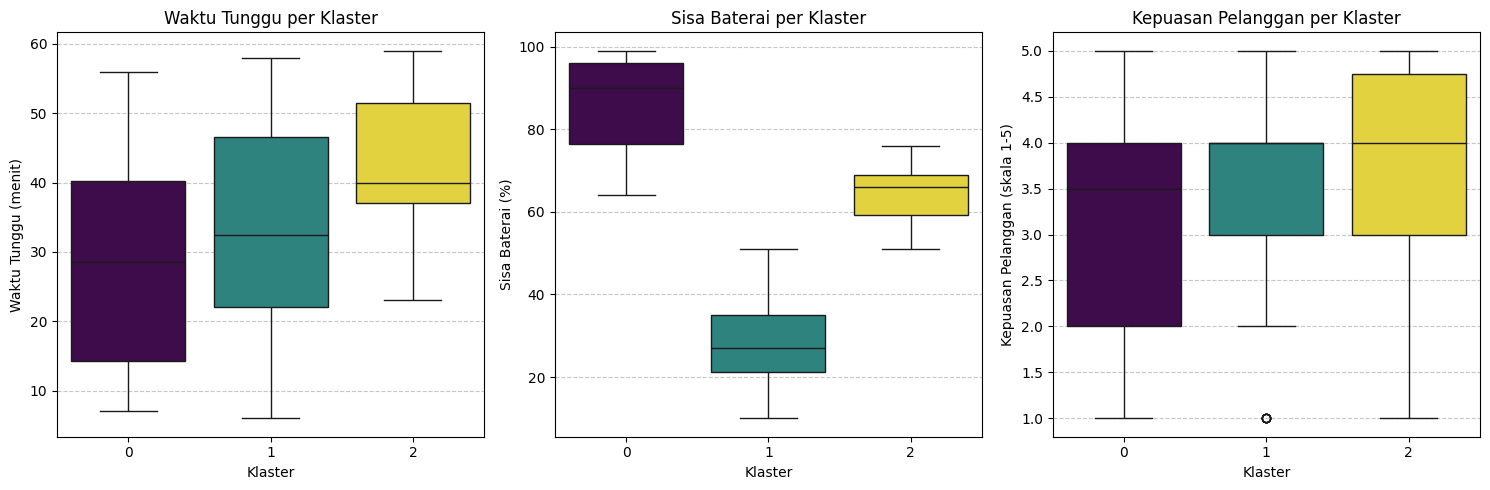

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='cluster', y='waktu_tunggu_menit', data=df_transformasi, palette='viridis', hue='cluster', legend=False)
plt.title('Waktu Tunggu per Klaster')
plt.xlabel('Klaster')
plt.ylabel('Waktu Tunggu (menit)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 3, 2)
sns.boxplot(x='cluster', y='sisa_baterai_persen', data=df_transformasi, palette='viridis', hue='cluster', legend=False)
plt.title('Sisa Baterai per Klaster')
plt.xlabel('Klaster')
plt.ylabel('Sisa Baterai (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 3, 3)
sns.boxplot(x='cluster', y='kepuasan_pelanggan', data=df_transformasi, palette='viridis', hue='cluster', legend=False)
plt.title('Kepuasan Pelanggan per Klaster')
plt.xlabel('Klaster')
plt.ylabel('Kepuasan Pelanggan (skala 1-5)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Kesimpulan Akhir Analisis Klastering

Berdasarkan hasil klastering K-Means dan visualisasi boxplot, berikut adalah ringkasan profil layanan setiap klaster:

| Klaster | Rata-rata Waktu Tunggu (menit) | Rata-rata Sisa Baterai (%) | Rata-rata Kepuasan Pelanggan (skala 1-5) | Jumlah Sampel | Interpretasi Profil Layanan |
|:-------:|:------------------------------:|:--------------------------:|:----------------------------------------:|:-------------:|:----------------------------|
|    0    |             28.7               |            86.5            |                   3.10                   |      20       | **Efisiensi Baterai Tinggi, Waktu Tunggu Moderat, Kepuasan Standar-Rendah.** Performa baterai sangat baik, namun waktu tunggu dan kepuasan perlu ditingkatkan. |
|    1    |             32.6               |            28.2            |                   3.50                   |      46       | **Waktu Tunggu Tinggi, Baterai Rendah, Kepuasan Standar.** Klaster paling bermasalah dengan waktu tunggu lama dan baterai kritis, mengindikasikan prioritas perbaikan. |
|    2    |             42.1               |            64.2            |                   3.47                   |      34       | **Waktu Tunggu Sangat Tinggi, Baterai Moderat, Kepuasan Standar.** Meskipun baterai cukup, waktu tunggu yang paling lama di klaster ini sangat mempengaruhi pengalaman pelanggan. |


**Rangkuman Tekstual:**

Analisis klastering berhasil mengidentifikasi tiga profil operasional shuttle yang berbeda. **Klaster 0** menunjukkan efisiensi baterai yang baik, namun menghadapi tantangan dalam waktu tunggu dan kepuasan pelanggan. **Klaster 1** adalah area yang paling membutuhkan perhatian mendesak, ditandai dengan waktu tunggu yang tinggi dan sisa baterai yang kritis, berdampak pada kepuasan yang relatif rendah. Sementara itu, **Klaster 2** memiliki masalah paling signifikan pada waktu tunggu, meskipun sisa baterai berada di tingkat moderat. Dengan memahami karakteristik ini, manajemen dapat mengembangkan strategi yang lebih tepat sasaran untuk meningkatkan efisiensi operasional dan kepuasan pelanggan.

### Rekomendasi Strategis Berdasarkan Profil Klaster

Berdasarkan profil layanan yang telah diidentifikasi melalui klastering, berikut adalah rekomendasi strategis yang dapat diterapkan untuk setiap klaster guna meningkatkan efisiensi operasional dan kepuasan pelanggan:

#### Klaster 0: Efisiensi Baterai Tinggi, Waktu Tunggu Moderat, Kepuasan Standar-Rendah

*   **Karakteristik Utama:** Shuttle di klaster ini memiliki manajemen baterai yang sangat baik (sisa baterai tinggi), namun waktu tunggu cenderung moderat hingga tinggi dan kepuasan pelanggan belum optimal.
*   **Rekomendasi Strategis:**
    *   **Optimalisasi Penjadwalan:** Fokus pada perbaikan penjadwalan rute untuk mengurangi waktu tunggu. Analisis pola permintaan dan sesuaikan alokasi shuttle.
    *   **Komunikasi Proaktif:** Berikan informasi real-time yang lebih akurat kepada pelanggan mengenai estimasi waktu tunggu untuk mengelola ekspektasi.
    *   **Pelatihan Pengemudi:** Tingkatkan pelatihan bagi pengemudi untuk mengidentifikasi dan mengatasi potensi keterlambatan secara proaktif.

#### Klaster 1: Waktu Tunggu Tinggi, Baterai Rendah, Kepuasan Standar

*   **Karakteristik Utama:** Ini adalah klaster yang paling bermasalah, ditandai dengan waktu tunggu yang tinggi dan sisa baterai yang kritis, yang berdampak pada kepuasan pelanggan yang rendah.
*   **Rekomendasi Strategis:**
    *   **Prioritas Pemeliharaan Baterai:** Lakukan inspeksi dan pemeliharaan rutin pada sistem baterai shuttle di klaster ini. Pertimbangkan penggantian baterai jika diperlukan.
    *   **Stasiun Pengisian Daya Tambahan:** Investasikan dalam penambahan stasiun pengisian daya di rute-rute yang dilalui oleh shuttle klaster ini untuk mengurangi durasi pengisian daya dan mencegah baterai kritis.
    *   **Peninjauan Rute Total:** Evaluasi ulang rute dan durasi perjalanan untuk shuttle di klaster ini. Mungkin ada inefisiensi rute atau beban kerja yang berlebihan.
    *   **Dukungan Darurat:** Siapkan tim respons cepat untuk shuttle yang mengalami masalah baterai atau waktu tunggu yang ekstrem.

#### Klaster 2: Waktu Tunggu Sangat Tinggi, Baterai Moderat, Kepuasan Standar

*   **Karakteristik Utama:** Shuttle di klaster ini memiliki waktu tunggu yang paling lama, meskipun kondisi baterai relatif moderat. Kepuasan pelanggan berada di tingkat standar.
*   **Rekomendasi Strategis:**
    *   **Re-evaluasi Kapasitas:** Periksa apakah kapasitas shuttle sudah sesuai dengan permintaan di area ini. Mungkin perlu penambahan unit shuttle atau pengalihan unit dari klaster lain.
    *   **Analisis Titik Hambatan:** Lakukan analisis mendalam untuk mengidentifikasi 'bottleneck' atau titik-titik kemacetan yang menyebabkan waktu tunggu sangat tinggi. Ini bisa berupa infrastruktur jalan, proses boarding, atau area penjemputan/pengantaran.
    *   **Implementasi Teknologi Cerdas:** Gunakan sistem navigasi atau manajemen lalu lintas yang lebih canggih untuk memprediksi dan menghindari kemacetan, serta mengoptimalkan rute secara real-time.
    *   **Umpan Balik Pelanggan:** Kumpulkan umpan balik spesifik dari pelanggan di klaster ini mengenai faktor-faktor yang menyebabkan waktu tunggu lama dan bagaimana hal itu memengaruhi pengalaman mereka.

### Ringkasan Eksekutif Laporan Proposal Penelitian

**Judul Penelitian:** Analisis Klastering untuk Optimalisasi Operasional dan Peningkatan Kepuasan Pelanggan Layanan Shuttle

**1. Latar Belakang & Permasalahan:**
Laporan ini menguraikan tantangan operasional yang dihadapi oleh layanan shuttle, khususnya terkait efisiensi waktu tunggu, manajemen sisa baterai, dan dampaknya terhadap kepuasan pelanggan. Kurangnya pemahaman mendalam tentang variasi profil operasional shuttle menghambat upaya perbaikan yang tepat sasaran.

**2. Metodologi:**
Penelitian ini menggunakan pendekatan *Data Mining* dengan algoritma Klastering K-Means. Data operasional shuttle, termasuk `waktu_tunggu_menit`, `sisa_baterai_persen`, dan `kepuasan_pelanggan`, dianalisis untuk mengidentifikasi kelompok-kelompok shuttle dengan karakteristik serupa. Proses ini melibatkan seleksi data, pembersihan (penanganan duplikasi dan nilai hilang), dan transformasi fitur untuk persiapan pemodelan.

**3. Temuan Utama:**
Analisis klastering berhasil mengelompokkan layanan shuttle ke dalam tiga profil berbeda:
*   **Klaster 0 (Efisiensi Baterai Tinggi, Waktu Tunggu Moderat, Kepuasan Standar-Rendah):** Menunjukkan manajemen baterai yang sangat baik, namun memerlukan perbaikan waktu tunggu dan peningkatan kepuasan pelanggan.
*   **Klaster 1 (Waktu Tunggu Tinggi, Baterai Rendah, Kepuasan Standar):** Klaster ini paling kritis, ditandai dengan waktu tunggu yang lama dan sisa baterai yang rendah, berdampak pada kepuasan pelanggan yang suboptimal. Membutuhkan intervensi mendesak.
*   **Klaster 2 (Waktu Tunggu Sangat Tinggi, Baterai Moderat, Kepuasan Standar):** Memiliki waktu tunggu terlama di antara klaster lainnya, meskipun kondisi baterai cukup. Perbaikan signifikan pada rute dan kapasitas diperlukan.

**4. Rekomendasi Strategis:**
Berdasarkan temuan ini, rekomendasi spesifik diformulasikan untuk setiap klaster:
*   **Untuk Klaster 0:** Fokus pada optimalisasi penjadwalan dan komunikasi proaktif dengan pelanggan.
*   **Untuk Klaster 1:** Prioritaskan pemeliharaan dan penambahan infrastruktur pengisian daya baterai, serta tinjauan rute total.
*   **Untuk Klaster 2:** Lakukan re-evaluasi kapasitas, analisis titik hambatan, dan implementasi teknologi cerdas untuk manajemen rute.

**5. Kesimpulan & Dampak:**
Analisis klastering ini memberikan wawasan yang jelas mengenai segmentasi profil operasional shuttle, memungkinkan manajemen untuk menyusun strategi yang lebih terfokus dan efisien. Dengan menerapkan rekomendasi ini, diharapkan dapat terjadi peningkatan signifikan dalam efisiensi operasional, pengurangan biaya, dan yang terpenting, peningkatan kepuasan pelanggan secara keseluruhan.

### Visualisasi Korelasi Antar Variabel dengan Heatmap

Untuk memahami hubungan antar variabel secara lebih mendalam, kita akan membuat heatmap dari matriks korelasi. Ini akan menunjukkan seberapa kuat dan ke arah mana (positif atau negatif) variabel-variabel numerik saling berhubungan.

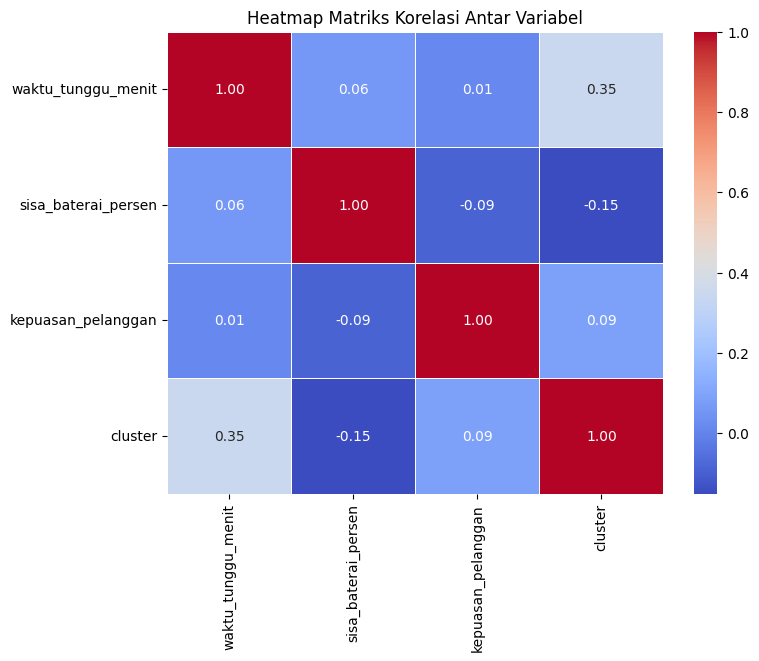

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pilih variabel numerik yang relevan untuk korelasi
# Menggunakan df_transformasi yang sudah ada
kolom_numerik_korelasi = ['waktu_tunggu_menit', 'sisa_baterai_persen', 'kepuasan_pelanggan', 'cluster']
korelasi_matrix = df_transformasi[kolom_numerik_korelasi].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(korelasi_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Heatmap Matriks Korelasi Antar Variabel')
plt.show()

### Ringkasan Rekomendasi Kebijakan Berdasarkan Korelasi Heatmap

Analisis korelasi memberikan wawasan tambahan mengenai hubungan antar variabel dan bagaimana hal tersebut memengaruhi klaster, yang kemudian dapat menjadi dasar rekomendasi kebijakan.

**1. Prioritaskan Pengurangan Waktu Tunggu di Klaster Bermasalah:**
*   **Dasar Korelasi:** Korelasi positif moderat (`0.35`) antara `waktu_tunggu_menit` dan `cluster` menunjukkan bahwa klaster dengan nomor yang lebih tinggi (seperti Klaster 2) secara konsisten mengalami waktu tunggu yang lebih lama. Ini juga didukung oleh Klaster 2 yang memiliki rata-rata waktu tunggu tertinggi.
*   **Rekomendasi Kebijakan:** Fokuskan kebijakan untuk mengidentifikasi dan mengatasi penyebab waktu tunggu yang ekstrem di klaster-klaster ini. Ini bisa mencakup:
    *   **Optimalisasi Rute Dinamis:** Implementasikan sistem rute yang adaptif terhadap kondisi lalu lintas real-time.
    *   **Penambahan Kapasitas:** Pertimbangkan penambahan unit shuttle atau pengalihan sumber daya ke area yang dilayani oleh klaster dengan waktu tunggu tinggi.
    *   **Analisis Titik Hambatan (Bottleneck):** Lakukan investigasi mendalam terhadap area atau jam sibuk yang menyebabkan penundaan signifikan.

**2. Tingkatkan Manajemen Sisa Baterai, Terutama di Klaster Berisiko:**
*   **Dasar Korelasi:** Korelasi negatif lemah hingga moderat (`-0.15`) antara `sisa_baterai_persen` dan `cluster` (dengan Klaster 1 memiliki sisa baterai terendah) mengindikasikan bahwa semakin 'tinggi' klaster atau klaster tertentu (seperti Klaster 1), cenderung memiliki sisa baterai yang lebih rendah.
*   **Rekomendasi Kebijakan:** Kembangkan kebijakan yang menjamin ketersediaan baterai yang memadai untuk semua shuttle, terutama yang termasuk dalam klaster dengan masalah baterai:
    *   **Pemeliharaan Preventif Baterai:** Jadwalkan pemeliharaan rutin dan penggantian baterai yang mendekati akhir masa pakainya.
    *   **Ekspansi Infrastruktur Pengisian Daya:** Bangun lebih banyak stasiun pengisian daya strategis di sepanjang rute untuk memungkinkan pengisian ulang yang lebih sering dan efisien.
    *   **Sistem Peringatan Dini:** Implementasikan sistem yang memberikan peringatan kepada pengemudi dan manajemen ketika sisa baterai mendekati level kritis.

**3. Pertimbangkan Faktor Lain dalam Peningkatan Kepuasan Pelanggan:**
*   **Dasar Korelasi:** Korelasi yang sangat lemah antara `kepuasan_pelanggan` dengan `waktu_tunggu_menit`, `sisa_baterai_persen`, maupun `cluster` (`0.01` hingga `0.09`) menunjukkan bahwa kepuasan pelanggan tidak hanya ditentukan secara linier oleh dua metrik operasional ini.
*   **Rekomendasi Kebijakan:** Walaupun perbaikan waktu tunggu dan baterai akan berkontribusi, kebijakan untuk meningkatkan kepuasan pelanggan harus lebih komprehensif:
    *   **Survei dan Umpan Balik Mendalam:** Lakukan survei kepuasan yang lebih detail untuk mengidentifikasi faktor-faktor lain yang memengaruhi pengalaman pelanggan (misalnya, kenyamanan shuttle, perilaku pengemudi, kemudahan pemesanan).
    *   **Pelatihan Layanan Pelanggan:** Tingkatkan pelatihan bagi pengemudi dan staf pendukung mengenai standar layanan dan interaksi pelanggan.
    *   **Program Loyalitas atau Insentif:** Pertimbangkan program yang memberikan nilai tambah kepada pelanggan setia.

**4. Pendekatan Berbasis Klaster untuk Implementasi Kebijakan:**
*   **Dasar Korelasi:** Kemampuan untuk mengidentifikasi klaster dengan karakteristik operasional yang berbeda (seperti yang ditunjukkan oleh korelasi dengan variabel `cluster`) memungkinkan kebijakan yang lebih bertarget.
*   **Rekomendasi Kebijakan:** Terapkan rekomendasi di atas secara adaptif sesuai dengan profil masing-masing klaster, bukan pendekatan 'satu ukuran untuk semua'. Misalnya, subsidi untuk stasiun pengisian daya mungkin lebih efektif di area Klaster 1, sementara optimalisasi rute lebih krusial untuk Klaster 2.

### Uji Signifikansi Perbedaan Rata-rata Waktu Tunggu Antar Klaster dengan ANOVA

Untuk memastikan apakah perbedaan rata-rata waktu tunggu yang terlihat antar klaster (berdasarkan analisis boxplot dan matriks centroid) adalah signifikan secara statistik, kita akan melakukan analisis varians (ANOVA).

In [ ]:
from scipy import stats

# Ekstrak 'waktu_tunggu_menit' untuk setiap klaster
cluster_0_waktu_tunggu = df_transformasi[df_transformasi['cluster'] == 0]['waktu_tunggu_menit']
cluster_1_waktu_tunggu = df_transformasi[df_transformasi['cluster'] == 1]['waktu_tunggu_menit']
cluster_2_waktu_tunggu = df_transformasi[df_transformasi['cluster'] == 2]['waktu_tunggu_menit']

# Lakukan uji ANOVA
f_statistic, p_value = stats.f_oneway(cluster_0_waktu_tunggu, cluster_1_waktu_tunggu, cluster_2_waktu_tunggu)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpretasi hasil
alpha = 0.05 # Tingkat signifikansi
if p_value < alpha:
    print("\nH0 ditolak: Terdapat perbedaan yang signifikan secara statistik pada rata-rata waktu tunggu antar klaster.")
else:
    print("\nH0 diterima: Tidak ada perbedaan yang signifikan secara statistik pada rata-rata waktu tunggu antar klaster.")

F-statistic: 7.19
P-value: 0.001

H0 ditolak: Terdapat perbedaan yang signifikan secara statistik pada rata-rata waktu tunggu antar klaster.


### Uji Post-Hoc Tukey HSD

Setelah uji ANOVA menunjukkan adanya perbedaan yang signifikan, langkah selanjutnya adalah melakukan uji *post-hoc* Tukey HSD (Honestly Significant Difference). Uji ini akan membantu kita menentukan pasangan klaster mana saja yang memiliki perbedaan rata-rata `waktu_tunggu_menit` yang signifikan secara statistik, sekaligus mengontrol *family-wise error rate*.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Lakukan uji Tukey HSD
# Menggunakan 'waktu_tunggu_menit' sebagai data, dan 'cluster' sebagai grup
tukey_result = pairwise_tukeyhsd(endog=df_transformasi['waktu_tunggu_menit'],
                                 groups=df_transformasi['cluster'],
                                 alpha=0.05) # Tingkat signifikansi yang sama

print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   3.9087 0.5459 -4.9322 12.7495  False
     0      2  13.3882 0.0026  4.0866 22.6899   True
     1      2   9.4795 0.0089  2.0143 16.9448   True
----------------------------------------------------


### Interpretasi Hasil Uji Tukey HSD

Kolom `reject` pada output Tukey HSD menunjukkan apakah hipotesis nol (tidak ada perbedaan rata-rata) ditolak untuk pasangan klaster tertentu:

*   **`True`**: Terdapat perbedaan rata-rata `waktu_tunggu_menit` yang signifikan secara statistik antara kedua klaster pada tingkat signifikansi 0.05.
*   **`False`**: Tidak terdapat perbedaan rata-rata `waktu_tunggu_menit` yang signifikan secara statistik antara kedua klaster pada tingkat signifikansi 0.05.

### Visualisasi Perbedaan Rata-rata Waktu Tunggu per Klaster dengan Boxplot

Untuk melengkapi hasil uji statistik, mari kita visualisasikan perbedaan distribusi `waktu_tunggu_menit` di antara klaster-klaster menggunakan boxplot. Ini akan memberikan gambaran intuitif tentang bagaimana waktu tunggu bervariasi di setiap kelompok.

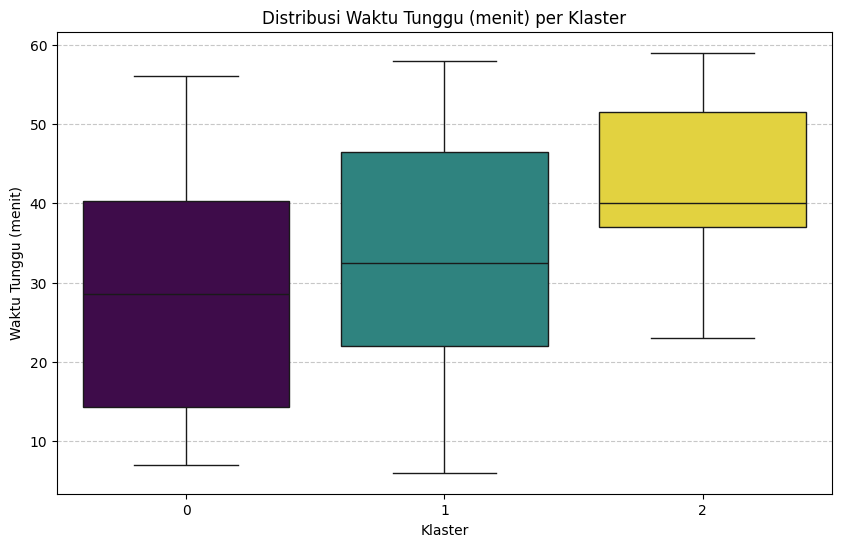

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='waktu_tunggu_menit', data=df_transformasi, palette='viridis', hue='cluster', legend=False)
plt.title('Distribusi Waktu Tunggu (menit) per Klaster')
plt.xlabel('Klaster')
plt.ylabel('Waktu Tunggu (menit)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Ringkasan Kesimpulan Uji Statistik dan Visualisasi Waktu Tunggu per Klaster
Uji ANOVA (Analisis Varians):

Hasil uji ANOVA menunjukkan F-statistic sebesar 7.19 dengan P-value sebesar 0.001. Karena P-value ini jauh lebih kecil dari tingkat signifikansi (alpha = 0.05), kita menolak hipotesis nol (H0). Ini berarti terdapat perbedaan yang signifikan secara statistik pada rata-rata waktu_tunggu_menit di antara ketiga klaster. Dengan kata lain, waktu tunggu rata-rata antar klaster tidaklah sama secara kebetulan.
Uji Post-Hoc Tukey HSD:

Untuk mengetahui pasangan klaster mana yang berbeda secara signifikan, uji Tukey HSD dilakukan:
Klaster 0 vs Klaster 1: P-adj sebesar 0.5459 (tidak signifikan). Tidak ada perbedaan statistik yang signifikan dalam waktu tunggu rata-rata antara Klaster 0 dan Klaster 1.
Klaster 0 vs Klaster 2: P-adj sebesar 0.0026 (signifikan). Terdapat perbedaan statistik yang signifikan dalam waktu tunggu rata-rata antara Klaster 0 dan Klaster 2.
Klaster 1 vs Klaster 2: P-adj sebesar 0.0089 (signifikan). Terdapat perbedaan statistik yang signifikan dalam waktu tunggu rata-rata antara Klaster 1 dan Klaster 2.
Kesimpulannya, Klaster 2 memiliki waktu_tunggu_menit yang berbeda secara signifikan dibandingkan dengan Klaster 0 dan Klaster 1, sedangkan Klaster 0 dan Klaster 1 tidak memiliki perbedaan yang signifikan satu sama lain.
Visualisasi Boxplot:

Boxplot waktu_tunggu_menit per klaster secara visual mendukung temuan uji statistik:
Klaster 0 menunjukkan distribusi waktu tunggu yang relatif lebih rendah dan terpusat.
Klaster 1 memiliki median waktu tunggu yang sedikit lebih tinggi daripada Klaster 0, dengan rentang yang serupa.
Klaster 2 secara jelas menampilkan distribusi waktu tunggu yang paling tinggi, dengan median dan kuartil atas yang jauh lebih besar dibandingkan Klaster 0 dan Klaster 1.
Kesimpulan Akhir: Secara keseluruhan, analisis statistik dan visualisasi secara konsisten menunjukkan bahwa Klaster 2 memiliki rata-rata waktu tunggu yang secara signifikan lebih lama dibandingkan dengan Klaster 0 dan Klaster 1. Perbedaan antara Klaster 0 dan Klaster 1 dalam hal waktu tunggu tidaklah signifikan. Temuan ini penting untuk memfokuskan upaya perbaikan operasional, terutama pada klaster dengan waktu tunggu yang paling ekstrem.